# E3 — BERTimbau treinado SÓ no ndmais (viés de domínio, protocolo básico T7c)

**Como rodar:** execute este notebook **3 vezes**, uma por razão, trocando só a variável `RAZAO` na célula seguinte: `"natural"` → `"1a64"` → `"1a10"`.
Mesmos hiperparâmetros do `bertimbau_tuning.ipynb` (lr 2e-5, 3 épocas, seed 42, bf16, batch efetivo 16).
Diferenças: treino só `ndmais.com.br`; peso de classe **só na `natural`** (1a64/1a10 sem peso, a subamostragem já é o ajuste — PLANO_VIES_DOMINIO.md E3);
checkpoints em `./resultados_bertimbau_ndmais_<RAZAO>/`; predições em `vies_dominio/ndmais_only/pred_bert_{dev,test,exposicao}_<RAZAO>.csv`.
Seleção pela **F1 no dev (corte 0.5)**; teste + exposição avaliados 1x para a razão vencedora. Sem bootstrap/AP na leitura básica.


In [2]:
# Setup do ambiente (rodar 1x; NAO atualiza o torch da imagem)
%pip install "transformers==5.18.0" datasets accelerate safetensors scikit-learn scipy matplotlib ipywidgets


Note: you may need to restart the kernel to use updated packages.


In [3]:
import logging
logging.getLogger().setLevel(logging.WARNING)  # silencia o barulho FFmpeg/torio do torchaudio

import torch
import transformers

print(f"Versao do PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__} | torch p/ Transformers: {transformers.is_torch_available()}")


Versao do PyTorch: 2.5.1+cu121
Transformers: 5.18.0 | torch p/ Transformers: True


PARTE 1 :
- Ativar GPU a ser utilzada para instalação e fine tunning do 'neuralmind/bert-base-portuguese-cased'
- Após o 'nvdia-smi' para ver o uso das placas de vídeo, conferir qual está livre e ajustar `CUDA_VISIBLE_DEVICES` na célula seguinte (em 2026-09-30: GPUs 0 e 1 livres, a 2 com 44GB ocupados)

In [4]:
import os


os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["USE_TF"] = "0"

import torch

# Verificando se a configuração funcionou
if torch.cuda.is_available():
    num_gpus = torch.cuda.device_count()
    gpu_name = torch.cuda.get_device_name(0)
    device = torch.device("cuda:0")
    print(f"GPUs disponíveis para o notebook: {num_gpus}")
    print(f"Placa em uso: {gpu_name}")
else:
    device = torch.device("cpu")
    print("CUDA não está disponível. Rodando na CPU.")

# 'device' é usado mais abaixo (pesos da loss, etc.) em vez de fixar "cuda:0" no código,
# assim o notebook não quebra se um dia rodar em outra máquina/sem GPU (ex.: smoke test).

GPUs disponíveis para o notebook: 1
Placa em uso: NVIDIA RTX A6000


In [5]:
print(f"Placa em uso: {gpu_name}")
print(torch.cuda.mem_get_info())   # (livre, total) em

Placa em uso: NVIDIA RTX A6000
(11020599296, 50908823552)


PARTE 1.1 (NOVO) — Reprodutibilidade

Na rodada anterior não havia seed fixa em nenhum lugar (split, inicialização do
cabeçalho de classificação, shuffle do `Trainer`). Com só ~560 exemplos de fraude
no treino, duas execuções idênticas podem dar F1 visivelmente diferente só por
causa da semente. Fixamos tudo aqui, no topo, antes de qualquer amostragem ou
inicialização de modelo.

Isso não elimina a variância — só torna cada execução individual reprodutível.
Para saber o quanto o resultado varia de fato, o item do checklist "rodar com
3–5 sementes" é o que responde isso; aqui só garantimos que uma mesma seed sempre
reproduz o mesmo resultado.

In [6]:
import random
import numpy as np
from transformers import set_seed

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
set_seed(SEED)  # também fixa a seed usada internamente pelo Trainer/Transformers

print(f"Seed fixada em {SEED}")

Seed fixada em 42


In [7]:
import transformers, torch
print(transformers.__version__, torch.__version__)
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
print("ok")

5.18.0 2.5.1+cu121
ok


PARTE 2:
- CARREGAMENTO DO DATASET;
- AJUSTE DOS DADOS;
- CONVERSÃO PARA COMPATIBILIDADE COM O FORMATO DO HUGGING FACE

**Mudança em relação à rodada anterior:** agora carregamos também o `test_bert.csv`.
Ele é o conjunto de teste (holdout) criado depois da auditoria de data leakage (já sem as linhas com similaridade TF-IDF ≥ 0,9 em relação ao treino/dev, ver `AUDITORIA_DATALEAKAGE.md` seção 7) —
serve só para a avaliação final, na PARTE 9, e não deve ser olhado (nem usado para
escolher hiperparâmetros, threshold, checkpoint, etc.) antes disso. Se ele influenciar
qualquer decisão antes da avaliação final, deixa de ser um teste independente.

In [8]:
import pandas as pd
from datasets import Dataset, DatasetDict

# >>> SELETOR DA RAZÃO — troque e rode o notebook de novo: "natural", "1a64" ou "1a10"
RAZAO = "natural"

TREINOS = {
    "natural": "vies_dominio/ndmais_only/train_natural.csv",
    "1a64": "vies_dominio/ndmais_only/train_1a64.csv",
    "1a10": "vies_dominio/ndmais_only/train_1a10.csv",
}
EXPOS = {
    "natural": "vies_dominio/ndmais_only/exposicao_1a106.csv",
    "1a64": "vies_dominio/ndmais_only/exposicao_1a64.csv",
    "1a10": "vies_dominio/ndmais_only/exposicao_1a10.csv",
}
assert RAZAO in TREINOS, f"RAZAO inválida: {RAZAO}"
TRAIN_PATH = TREINOS[RAZAO]
DEV_PATH = "vies_dominio/ndmais_only/dev.csv"
TEST_PATH = "vies_dominio/ndmais_only/test.csv"  # in-domain ndmais, só usado na PARTE 9
EXPO_PATH = EXPOS[RAZAO]  # exposição cross-portal da MESMA razão — só avaliar depois de escolher no dev

# 2. Carregamento dos dados (mantendo todas as colunas: url, processed_text, label, portal)
df_treino_full = pd.read_csv(TRAIN_PATH)
df_dev_full = pd.read_csv(DEV_PATH)
df_teste_full = pd.read_csv(TEST_PATH)
df_expo_full = pd.read_csv(EXPO_PATH)

for nome, df in [("treino", df_treino_full), ("dev", df_dev_full), ("teste", df_teste_full), ("exposicao", df_expo_full)]:
    assert {"url", "processed_text", "label", "portal"}.issubset(df.columns), \
        f"{nome}: colunas esperadas ausentes, achei {list(df.columns)}"

print(f"RAZAO={RAZAO} | treino: {len(df_treino_full)} | dev: {len(df_dev_full)} | teste: {len(df_teste_full)} | exposicao: {len(df_expo_full)}")


RAZAO=natural | treino: 28985 | dev: 7351 | teste: 9091 | exposicao: 11379


In [9]:
print("TREINO\n", df_treino_full["label"].value_counts())
print("\n\nDEV\n", df_dev_full["label"].value_counts())
print("\n\nTESTE (holdout — só olhar de novo na PARTE 9)\n", df_teste_full["label"].value_counts())

TREINO
 label
0    28715
1      270
Name: count, dtype: int64


DEV
 label
0    7292
1      59
Name: count, dtype: int64


TESTE (holdout — só olhar de novo na PARTE 9)
 label
0    9010
1      81
Name: count, dtype: int64


PARTE 2.1 (NOVO) — Checagem automática de vazamento entre splits

A auditoria (`AUDITORIA_DATALEAKAGE.md`) e o script `checagem_leakage.py` já
confirmaram, numa análise offline, que:

- não há duplicata exata/normalizada de `processed_text` entre treino, dev e teste;
- não há URL repetida entre os três splits;
- as quase-duplicatas com similaridade TF-IDF ≥ 0,9 foram removidas do teste (seção 7 da auditoria); ainda restam pares entre 0,8 e 0,9 e quase-duplicatas em dev/treino (parte 1/parte 2, matérias republicadas) e um
  desbalanceamento forte de fraude por portal — isso é tratado no checklist, não aqui.

Essa célula **não substitui** o `checagem_leakage.py` (que faz a checagem completa,
incluindo TF-IDF e é pesado demais para rodar a cada execução do notebook).
Ela é um guard-rail leve: refaz só a parte barata (hash exato/normalizado + URL) toda
vez que o notebook roda, para pegar na hora um erro bobo (por exemplo, alguém
sobrescrever `test_bert.csv` com uma versão sem dedup) antes de começar a tokenizar.

In [10]:
import hashlib
import re


def _hash_norm(texto):
    norm = re.sub(r"\s+", " ", str(texto)).strip()
    return hashlib.md5(norm.encode("utf-8")).hexdigest()


PARAR_SE_FALHAR = False  # True = interrompe o notebook se achar vazamento; False = só avisa

splits = {"train": df_treino_full, "dev": df_dev_full, "test": df_teste_full}
hashes = {nome: set(df["processed_text"].map(_hash_norm)) for nome, df in splits.items()}
urls = {nome: set(df["url"]) for nome, df in splits.items()}

problemas = []
pares = [("train", "dev"), ("train", "test"), ("dev", "test")]
for a, b in pares:
    inter_texto = hashes[a] & hashes[b]
    inter_url = urls[a] & urls[b]
    print(f"{a} x {b} -> {len(inter_texto)} textos em comum, {len(inter_url)} URLs em comum")
    if inter_texto or inter_url:
        problemas.append((a, b, len(inter_texto), len(inter_url)))

for nome, df in splits.items():
    dup_intra = df["processed_text"].map(_hash_norm).duplicated().sum()
    print(f"{nome}: {dup_intra} duplicatas internas (mesmo texto normalizado)")
    if dup_intra:
        problemas.append((nome, nome, dup_intra, 0))

if problemas:
    msg = f"ATENÇÃO: checagem de vazamento encontrou {len(problemas)} problema(s): {problemas}"
    if PARAR_SE_FALHAR:
        raise AssertionError(msg)
    print("\n" + msg)
else:
    print("\nOK — sem duplicata exata/normalizada nem URL repetida entre os splits.")

print("\nLembrete: isto cobre só duplicata exata/normalizada e URL. Quase-duplicatas,\n"
      "concentração de fraude por portal e truncamento >512 tokens são tratados no\n"
      "checagem_leakage.py e no checklist — não são pegos por esta célula.")

train x dev -> 0 textos em comum, 0 URLs em comum
train x test -> 0 textos em comum, 0 URLs em comum
dev x test -> 0 textos em comum, 0 URLs em comum
train: 0 duplicatas internas (mesmo texto normalizado)
dev: 0 duplicatas internas (mesmo texto normalizado)
test: 0 duplicatas internas (mesmo texto normalizado)

OK — sem duplicata exata/normalizada nem URL repetida entre os splits.

Lembrete: isto cobre só duplicata exata/normalizada e URL. Quase-duplicatas,
concentração de fraude por portal e truncamento >512 tokens são tratados no
checagem_leakage.py e no checklist — não são pegos por esta célula.


PARTE 2.2 (NOVO) — Peso de classe calculado a partir dos dados

Na rodada anterior o peso `64.2` estava escrito direto no código (na célula do
`WeightedLossTrainer`, mais abaixo), calculado à mão a partir da contagem antiga
(`36090 / 562`). Como os datasets podem mudar (novo `test_bert.csv`, futuras
correções de portal), calculamos o peso aqui, a partir do `df_treino_full` que
acabou de ser carregado — assim ele nunca fica desatualizado.

In [11]:
n_neg = (df_treino_full["label"] == 0).sum()
n_pos = (df_treino_full["label"] == 1).sum()
peso_fraude = n_neg / n_pos

print(f"Treino: {n_neg} normais / {n_pos} fraudes -> peso da classe FRAUDE = {peso_fraude:.2f}")
print("(valor usado mais abaixo na WeightedLossTrainer, em vez de um número fixo no código)")

Treino: 28715 normais / 270 fraudes -> peso da classe FRAUDE = 106.35
(valor usado mais abaixo na WeightedLossTrainer, em vez de um número fixo no código)


In [12]:
# 3. Preparação das colunas (igual ao notebook principal + conjunto de exposição)
df_treino_full = df_treino_full.rename(columns={"processed_text": "text"})
df_dev_full = df_dev_full.rename(columns={"processed_text": "text"})
df_teste_full = df_teste_full.rename(columns={"processed_text": "text"})
df_expo_full = df_expo_full.rename(columns={"processed_text": "text"})

# Isolamos apenas as colunas textuais e de classificação para economizar memória
df_treino = df_treino_full[["text", "label"]]
df_dev = df_dev_full[["text", "label"]]
df_teste = df_teste_full[["text", "label"]]
df_expo = df_expo_full[["text", "label"]]


In [13]:
df_treino.columns

Index(['text', 'label'], dtype='object')

In [14]:
# 4. Conversão para o formato Hugging Face
dataset_treino = Dataset.from_pandas(df_treino)
dataset_dev = Dataset.from_pandas(df_dev)
dataset_teste = Dataset.from_pandas(df_teste)
dataset_expo = Dataset.from_pandas(df_expo)  # E3 — só usado na avaliação final da exposição


In [15]:
print(len(dataset_teste), len(dataset_expo))
print(dataset_treino.shape)


9091 11379
(28985, 2)


In [17]:
dataset_treino[0]

{'text': 'Florianópolis tem 23 locais fechados desde fevereiro por descumprirem normas sanitárias Mais de mil ações de vistorias referentes ao cumprimento das medidas sanitárias contra a disseminação da Covid-19 já foram realizadas em Florianópolis desde fevereiro. Neste período, foram 1.074 vistorias, 41 advertências, 258 intimações, 18 multas, 23 locais interditados e 712 estabelecimentos operando dentro das normas, segundo aPrefeitura. Entre os estabelecimentos estãobares, pubs, restaurantes, lojas, shoppings, supermercados, hotéis, além de locais públicos como parques e praias. Somente neste final de semana foram realizadas 129 inspeções, uma advertência, uma multa, 18 intimações e uma interdição cautelar executada. Nas fiscalizações são verificados itens comouso correto de máscaras, distanciamento social, disposição de mesas e cadeiras, disponibilidade de álcool em gel, sistema de ventilação, exposição dos alvarás de funcionamento em locais visíveis e outras regras sanitárias. Com

In [20]:
 dataset_treino["text"]

Column(['Florianópolis tem 23 locais fechados desde fevereiro por descumprirem normas sanitárias Mais de mil ações de vistorias referentes ao cumprimento das medidas sanitárias contra a disseminação da Covid-19 já foram realizadas em Florianópolis desde fevereiro. Neste período, foram 1.074 vistorias, 41 advertências, 258 intimações, 18 multas, 23 locais interditados e 712 estabelecimentos operando dentro das normas, segundo aPrefeitura. Entre os estabelecimentos estãobares, pubs, restaurantes, lojas, shoppings, supermercados, hotéis, além de locais públicos como parques e praias. Somente neste final de semana foram realizadas 129 inspeções, uma advertência, uma multa, 18 intimações e uma interdição cautelar executada. Nas fiscalizações são verificados itens comouso correto de máscaras, distanciamento social, disposição de mesas e cadeiras, disponibilidade de álcool em gel, sistema de ventilação, exposição dos alvarás de funcionamento em locais visíveis e outras regras sanitárias. Como

In [21]:
print(dataset_treino.features)      # tipos de cada coluna
print(dataset_treino.num_rows)      # 36650
print(type(dataset_treino.data))    # a tabela Arrow por baixo

{'text': Value('string'), 'label': Value('int64')}
28985
<class 'datasets.table.InMemoryTable'>


In [22]:
# 5. Agrupamento estruturado
dataset_hf = DatasetDict({
    "train": dataset_treino,
    "validation": dataset_dev,
    "test": dataset_teste,  # só usado na PARTE 9
    "exposure": dataset_expo,  # E3 — só avaliado depois da escolha no dev
})

# Verificando a estrutura final carregada
print(dataset_hf)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 28985
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 7351
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 9091
    })
    exposure: Dataset({
        features: ['text', 'label'],
        num_rows: 11379
    })
})


PARTE 3: Tokenização

**Mudança em relação à rodada anterior:** foi tirado o `padding='max_length'` da função
de tokenização. Antes, todo texto virava 512 tokens, mesmo os textos curtos (a
mediana de caracteres do dataset dá bem menos que 512 tokens) — isso desperdiça
memória e tempo de treino à toa, processando um monte de padding sem informação.
Trocamos por *padding dinâmico*: cada lote é preenchido só até o tamanho do maior
texto daquele lote específico, feito pelo `DataCollatorWithPadding` (célula mais
abaixo, perto do `Trainer`). O truncamento em 512 tokens continua igual.

In [23]:
from transformers import AutoTokenizer

# 1. Instanciando o tokenizador oficial do BERTimbau
modelo = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(modelo)


# 2. Criando a função de tokenização
def tokenizar_batch(batch):
    # Aplica só o truncamento aqui; o padding é feito depois, por lote, pelo
    # DataCollatorWithPadding (padding dinâmico, em vez de fixar 512 para tudo)
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
    )


# 3. Aplicando a função a todo o dataset
# O parâmetro batched=True é fundamental aqui. Ele usa a infraestrutura em C++ do Apache Arrow
# para tokenizar milhares de textos por segundo de forma assíncrona.
dataset_tokenizado = dataset_hf.map(tokenizar_batch, batched=True)

# 4. Verificando as novas colunas criadas
print("Colunas originais:", dataset_hf["train"].column_names)
print("Colunas após tokenização:", dataset_tokenizado["train"].column_names)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/28985 [00:00<?, ? examples/s]

Map:   0%|          | 0/7351 [00:00<?, ? examples/s]

Map:   0%|          | 0/9091 [00:00<?, ? examples/s]

Map:   0%|          | 0/11379 [00:00<?, ? examples/s]

Colunas originais: ['text', 'label']
Colunas após tokenização: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask']


In [24]:
dataset_tokenizado["train"]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 28985
})

In [25]:
print(dataset_tokenizado["train"][2])

{'text': 'Empresa pede anulação do processo do complexo na Serra do Rio do Rastro Contemplada pelas belezas da natureza, a região Sul de Santa Catarina vem crescendo como atração turística. Na Serra do Rio Rastro, uma das propostas é a construção de um complexo turístico. Os primeiros procedimentos licitatórios já foram feitos. Tem empresa vencedora para a construção da estrutura, mas um recurso na justiça determina a paralisação do processo.', 'label': 0, 'input_ids': [101, 18725, 7935, 360, 1163, 171, 1673, 171, 5181, 229, 4553, 171, 1007, 171, 15505, 552, 11433, 350, 15770, 1676, 7828, 22281, 180, 3402, 117, 123, 1079, 1422, 125, 1838, 5193, 3539, 15655, 271, 8988, 18734, 119, 503, 4553, 171, 1007, 15505, 552, 117, 230, 366, 8658, 253, 123, 1803, 125, 222, 5181, 14991, 119, 533, 1867, 12275, 4073, 343, 2926, 770, 506, 5159, 119, 2501, 1799, 12258, 221, 123, 1803, 180, 2388, 117, 449, 222, 8190, 229, 6722, 10439, 123, 13628, 341, 171, 1673, 119, 102], 'token_type_ids': [0, 0, 0, 0, 0

PARTE 3.1 (NOVO) — Quanto texto está sendo cortado em 512 tokens?

A checagem feita em `checagem_leakage.py` (`truncamento_por_classe.csv`) mostrou que,
nos splits atuais, o truncamento em 512 tokens é bem mais frequente nos positivos
(fraude) do que nos negativos:

| split | label | mediana tokens | q75 | % truncado |
|---|---|---|---|---|
| dev | 0 (normal) | 381 | 594 | 32,3% |
| dev | 1 (fraude) | 734 | 960 | **73,0%** |
| test | 0 (normal) | 380 | 598 | 33,0% |
| test | 1 (fraude) | 712 | 1136 | **74,3%** |

Ou seja: quase 3 em cada 4 matérias de fraude têm o final cortado. Se a informação
decisiva (valor desviado, nome do investigado, desfecho do processo) tende a
aparecer mais para o fim da matéria, o modelo majoritariamente não a vê. Reproduzimos
a mesma medida aqui embaixo, agora no treino, para acompanhar a cada rodada.

In [26]:
import numpy as np

MAX_LEN = 512


def stats_truncamento(df, nome):
    # truncation=False + sem padding: comprimento real do texto em tokens
    n_tokens = [len(ids) for ids in tokenizer(list(df["text"]), truncation=False)["input_ids"]]
    n_tokens = np.array(n_tokens)
    trunc = (n_tokens > MAX_LEN).mean() * 100
    print(f"{nome:8s} mediana={np.median(n_tokens):.0f}  q75={np.percentile(n_tokens, 75):.0f}  "
          f"%>{MAX_LEN}tok={trunc:.1f}%  (n={len(df)})")
    return n_tokens


print("--- treino ---")
for lbl, nome in [(0, "normal"), (1, "fraude")]:
    stats_truncamento(df_treino[df_treino["label"] == lbl], nome)

--- treino ---
normal   mediana=335  q75=548  %>512tok=27.9%  (n=28715)
fraude   mediana=583  q75=944  %>512tok=58.9%  (n=270)


Função alternativa (não usada por padrão): truncamento início+fim

Em vez de manter só os primeiros 512 tokens, esta função mantém um pedaço do
início e um pedaço do fim do texto. É uma forma barata de testar se o modelo
melhora quando não perde o desfecho da matéria — fica pronta aqui para o item do
checklist que compara as duas estratégias, mas **não está conectada ao pipeline
principal**: `dataset_tokenizado` (célula acima) continua usando truncamento
simples, para manter esta rodada comparável com a anterior. Trocar de estratégia
é uma decisão a se tomar depois de olhar os números da PARTE 9, não antes.

In [ ]:
# OPÇÃO A SER RODADA POSTERIORMENTE, SE QUISER COMPARAR COM OS 512 TOKENS INICIAIS 
#COMO SERIAM OS RESULTADOS UTILIZANDO PARTE DO INÍCIO E PARTE DO FIM

def tokenizar_head_tail(textos, tokenizer, max_length=512, tokens_do_inicio=128):
    """Mantém `tokens_do_inicio` tokens do começo + o resto do orçamento vindo do final do texto.
    Uso: tokenizar_head_tail(df_treino["text"].tolist(), tokenizer)
    """
    tokens_do_fim = max_length - tokens_do_inicio - 2  # -2 para [CLS] e [SEP]
    saida = {"input_ids": [], "attention_mask": [], "token_type_ids": []}
    for texto in textos:
        ids = tokenizer.encode(texto, add_special_tokens=False)
        if len(ids) > max_length - 2:
            ids = ids[:tokens_do_inicio] + ids[-tokens_do_fim:]
        ids = [tokenizer.cls_token_id] + ids[: max_length - 2] + [tokenizer.sep_token_id]
        pad = max_length - len(ids)
        saida["input_ids"].append(ids + [tokenizer.pad_token_id] * pad)
        saida["attention_mask"].append([1] * len(ids) + [0] * pad)
        saida["token_type_ids"].append([0] * max_length)
    return saida

PARTE 5: Demonstração de embeddings

Célula original, só para enxergar o que sai do BERT antes de acoplar a cabeça de
classificação — carrega o modelo "cru" (`AutoModel`, sem cabeça) numa instância
separada, só para inspecionar o embedding de um token. Isto não participa do
treino; a limpeza de memória (célula seguinte) é nova, para não deixar essa cópia
extra do modelo ocupando VRAM depois de já termos visto o que precisávamos ver.

In [28]:
import torch
from transformers import AutoModel

# 1. Carregue o modelo (use o exato modelo BERT que você escolheu no tokenizer)
# Exemplo: 'bert-base-uncased' ou o modelo em português 'neuralmind/bert-base-portuguese-cased'
nome_do_mode = "neuralmind/bert-base-portuguese-cased"
mode = AutoModel.from_pretrained(nome_do_mode, use_safetensors=True)

# 2. Pegue os dados do exemplo 2 do seu dataset
exemplo = dataset_tokenizado["train"][2]

# 3. Converta as listas do dataset em Tensores do PyTorch adicionando a dimensão de lote [Batch]
input_ids = torch.tensor([exemplo["input_ids"]])          # Formato: [1, T]
attention_mask = torch.tensor([exemplo["attention_mask"]])  # Formato: [1, T]

# 4. Passe pelo BERT sem calcular gradientes (modo de inferência)
with torch.no_grad():
    saidas = mode(input_ids=input_ids, attention_mask=attention_mask)

# 5. Pegue a matriz empilhada de embeddings da última camada
# O formato de 'embeddings_empilhados' será: [1, T, 768] -> [Lote, Tokens, Colunas]
embeddings_empilhados = saidas.last_hidden_state

# 6. Acesse o primeiro token (índice 0, que possui o ID 101)
embedding_do_id_101 = embeddings_empilhados[0, 0, :]

# Visualização dos resultados
print(f"Formato da matriz empilhada do texto: {embeddings_empilhados.shape}")
print(f"Formato do vetor do token 101: {embedding_do_id_101.shape}")
print("\nPrimeiros 15 valores numéricos (das 768 colunas) do ID 101:")
print(embedding_do_id_101[:15])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Formato da matriz empilhada do texto: torch.Size([1, 87, 768])
Formato do vetor do token 101: torch.Size([768])

Primeiros 15 valores numéricos (das 768 colunas) do ID 101:
tensor([-0.3160, -0.2601,  0.2022,  0.0062,  0.0952, -0.1927,  0.4178,  0.1403,
        -0.0508,  0.2137, -0.2839,  0.4860, -0.6743,  0.1839, -0.0230])


In [29]:
print(embedding_do_id_101[:])

tensor([-3.1600e-01, -2.6006e-01,  2.0223e-01,  6.2466e-03,  9.5165e-02,
        -1.9275e-01,  4.1782e-01,  1.4034e-01, -5.0850e-02,  2.1365e-01,
        -2.8390e-01,  4.8602e-01, -6.7432e-01,  1.8394e-01, -2.2994e-02,
         5.5078e-01, -1.2976e-01,  3.2677e-01,  1.4091e-01, -1.3401e-01,
         3.0807e-02,  1.0131e-01,  5.2959e-01, -2.6197e-01,  3.6128e-01,
         3.8417e-01, -6.0809e-02,  4.8075e-01,  3.4056e-03,  2.4242e-01,
        -2.9915e-01,  5.1963e-01, -1.5016e-03, -3.4309e-01,  8.0024e-02,
        -4.3849e-01,  1.8527e-01, -6.8873e-02, -1.5125e-01,  1.6560e-01,
         2.6615e-01, -1.2152e-01, -2.3463e-01,  3.2199e-01,  1.5715e-01,
        -1.6248e-01, -3.8013e-01, -9.1979e-02,  1.3381e-01,  4.5712e-01,
        -2.2460e-01,  3.5939e-01, -1.4235e-02,  2.3016e-01,  5.2128e-01,
         2.6023e-02,  1.4971e-01, -1.0771e-01, -4.5663e-01, -4.3553e-01,
         3.3616e-01, -1.7220e-01,  4.3269e-01,  5.5971e-02, -4.6291e-01,
        -3.3427e-01,  9.8270e-02, -1.1853e-01,  8.9

In [30]:
# NOVO — libera a instância de demonstração antes de carregar o modelo de classificação
del mode, saidas, embeddings_empilhados, embedding_do_id_101, input_ids, attention_mask
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Memória da demonstração liberada.")

Memória da demonstração liberada.


PARTE 6: Métricas de avaliação

**Mudança em relação à rodada anterior:** além de accuracy/precision/recall/F1,
agora também calculamos a *Average Precision* (área sob a curva precision-recall,
`ap`) e os quatro números da matriz de confusão (`tp`, `fp`, `fn`, `tn`). O F1
depende do limiar de decisão (0,5 implícito no `argmax`); a AP resume a qualidade
do modelo em todos os limiares possíveis, o que é mais informativo quando, como
aqui, o limiar pode vir a ser ajustado depois (ver checklist).

In [31]:
# definindo f1-score como metrica principal para o aprendizado

import numpy as np
from scipy.special import softmax
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, average_precision_score, confusion_matrix


# 1. Definindo a função de avaliação
def compute_metrics(eval_pred):
    # O modelo entrega tuplas contendo suas "certezas" matemáticas (logits) e o gabarito (labels)
    logits, labels = eval_pred

    # Extraímos a decisão final do modelo pegando o maior valor (argmax)
    predictions = np.argmax(logits, axis=-1)

    # Probabilidade da classe FRAUDE (para a average precision, que olha todos os limiares)
    proba_fraude = softmax(logits, axis=-1)[:, 1]

    # Calculamos as métricas usando a classe minoritária/alvo (fraude = 1) como base
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="binary")
    acc = accuracy_score(labels, predictions)
    ap = average_precision_score(labels, proba_fraude)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()

    # O Hugging Face espera receber um dicionário com os resultados
    return {
        "accuracy": acc,
        "f1": f1,
        "precision": precision,
        "recall": recall,
        "ap": ap,  # NOVO — average precision, independe do limiar 0.5
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),  # NOVO — para ler a matriz de confusão direto no log
    }

1. O que são os logits e o argmax?A rede neural não cospe imediatamente um 0 ou 1. A última camada do modelo (o "cabeçalho" de classificação) produz valores brutos contínuos chamados logits.Para uma notícia específica, o modelo pode gerar um vetor como [4.5, -1.2].O primeiro valor representa a energia/probabilidade de ser 0 (Normal).O segundo valor representa a energia para ser 1 (Fraude).A função np.argmax(logits, axis=-1) percorre esse vetor e escolhe o índice do maior número. Como $4.5 > -1.2$, o argmax retorna o índice 0. É assim que a "opinião" matemática da rede se transforma em uma decisão binária concreta.2. A Matemática das Métricas (Scikit-Learn)Avaliar apenas a Acurácia (a porcentagem de acertos totais) é perigoso em contextos onde fraudes são raras (classes desbalanceadas), pois o modelo poderia "trapacear" chutando 0 para tudo e ainda assim obter 99% de acerto. É por isso que extraímos a Precision e o Recall.Matematicamente, o Scikit-Learn constrói uma Matriz de Confusão para contar os Verdadeiros Positivos ($TP$), Falsos Positivos ($FP$) e Falsos Negativos ($FN$), aplicando as seguintes equações:Precisão (Precision): De todos os contratos que o modelo apontou como fraudulentos, quantos realmente eram? É uma medida de cautela; alta precisão significa poucos alarmes falsos.$$Precision = \frac{TP}{TP + FP}$$Revocação (Recall): De todas as fraudes reais que existiam ocultas nos dados, quantas o modelo conseguiu capturar? É uma medida de sensibilidade; alto recall significa que poucas infrações escaparam do radar.$$Recall = \frac{TP}{TP + FN}$$F1-Score: Como Precision e Recall costumam ser uma balança (quando você aumenta um, o outro tende a cair), o F1-Score calcula a média harmônica entre os dois, criando uma única métrica definitiva de qualidade para o seu modelo.$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

**(NOVO) 3. E a Average Precision (`ap`)?** O F1 acima usa um limiar fixo (o
`argmax`, equivalente a 0,5). A Average Precision resume o comportamento do
modelo considerando *todos* os limiares possíveis — é a área sob a curva
precision-recall. Ela é o número certo para comparar modelos ou decidir depois
qual limiar usar (por exemplo, se o Ministério Público preferir mais recall à
custa de precision), sem estar amarrada à escolha de corte em 0,5.

In [ ]:
# pip install transformers[torch] - PUlada no momento, pois o ambiente já está configurado

PARTE 7: Configuração do treino

**Mudanças em relação à rodada anterior:** `seed=SEED` (reprodutibilidade),
`bf16=True` (a RTX A6000 suporta precisão mista bfloat16 — acelera o treino e usa
menos memória, sem a instabilidade numérica que fp16 pode ter) e
`save_total_limit=2` (evita acumular um checkpoint por época em disco à toa).

In [32]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

# 1. Dicionários de mapeamento
id2label = {0: "NORMAL", 1: "FRAUDE"}
label2id = {"NORMAL": 0, "FRAUDE": 1}

# 2. Carregando a arquitetura do modelo
modelo_classificacao = AutoModelForSequenceClassification.from_pretrained(
    modelo,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
    use_safetensors=True,
)

# 3. Definindo as regras do treinamento (iguais ao notebook principal; só muda o output_dir por razão)
training_args = TrainingArguments(
    output_dir=f"./resultados_bertimbau_ndmais_{RAZAO}",
    seed=SEED,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_strategy="steps",
    logging_steps=200,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    bf16=torch.cuda.is_available(),
    load_best_model_at_end=True,
    metric_for_best_model="f1",
)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


1. A Troca de "Cabeçalho" (AutoModelForSequenceClassification)O BERTimbau original passou meses lendo a internet apenas para aprender português (tarefa de Language Modeling). Ao usarmos o AutoModelForSequenceClassification, o código entra na arquitetura original, arranca a última camada neural (o "cabeçalho" que adivinhava palavras) e acopla uma nova camada linear crua com exatamente 2 saídas (num_labels=2). O resto da rede já é fluente em português, mas essa última camada nova não sabe nada; ela será treinada do zero para associar os padrões semânticos às suas fraudes. Ao rodar essa célula, é provável que você veja um aviso em vermelho dizendo que alguns pesos não foram inicializados. Isso é perfeitamente normal e esperado; é o aviso de que o novo cabeçalho cru foi acoplado com sucesso.

2. Tamanho do Lote (batch_size = 16)Como você está trabalhando com textos longos (max_length=512), as matrizes de cálculo ficam enormes. Placas de vídeo comuns com 16GB ou mais costumam suportar esse tamanho, principalmente com precisão mista. Como você está utilizando a RTX A6000 (que tem uma VRAM gigantesca de 48GB), ela consegue absorver 16 (ou até 32) textos inteiros simultaneamente, paralelizando as multiplicações matriciais e reduzindo drasticamente o tempo de cada época.

3. A Taxa de Aprendizado (learning_rate = 2e-5)Isso é o $0.00002$. Na teoria da descida do gradiente (Gradient Descent), a taxa de aprendizado dita o tamanho dos "passos" que a rede dá para corrigir seus erros. Se for muito grande, o modelo destrói o conhecimento prévio de português do BERT. Se for muito pequena, ele não aprende a detectar as fraudes. Para o BERT, o padrão-ouro validado pela academia fica entre 2e-5 e 5e-5.

**(NOVO) 4. Por que `bf16=True`?** É precisão mista: parte das contas do treino
passa a usar números de 16 bits (bfloat16) em vez de 32 bits, o que praticamente
não muda o resultado final mas acelera o treino e reduz o uso de VRAM — vantagem
livre numa GPU que já suporta isso, como a A6000.

In [33]:
print(torch.cuda.mem_get_info())

(34712125440, 50908823552)


Você acaba de concluir toda a preparação estrutural. O próximo passo no código é, literalmente, acionar a rede neural — mas antes disso, criamos o `data_collator` que faz o padding dinâmico (PARTE 3) e a classe `WeightedLossTrainer`, que já usa o `peso_fraude` calculado na PARTE 2.2 em vez de um número fixo.

Execute a célula do seu Jupyter que contém a nossa classe `WeightedLossTrainer` (onde injetamos os pesos para o balanceamento de classes). Logo abaixo dela, crie uma nova célula em branco, insira o comando de ignição e execute-o:

```python
# Inicia o treinamento (Fine-Tuning) na RTX A6000
trainer.train()
```

---

In [34]:
import torch
from torch import nn
from transformers import Trainer, DataCollatorWithPadding

# E3: peso de classe SÓ na razão natural (1a64/1a10 sem peso — a subamostragem já é o ajuste).
# `peso_fraude` foi calculado na PARTE 2.2 a partir do treino atual.
peso_usado = peso_fraude if RAZAO == "natural" else 1.0
print(f"RAZAO={RAZAO} -> peso da classe FRAUDE na loss = {peso_usado:.2f}")
pesos_classes = torch.tensor([1.0, peso_usado], dtype=torch.float32).to(device)


# 2. Criando a Subclasse Customizada - com **kwargs na memoria
class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        # Extrai o gabarito (labels) do lote atual
        labels = inputs.pop("labels")

        # Passa os textos pela rede neural
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Aplica a matemática com penalidade
        loss_fct = nn.CrossEntropyLoss(weight=pesos_classes)

        # Calcula a diferença entre a predição (logits) e a realidade (labels)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


# NOVO — padding dinâmico: cada lote é preenchido só até o maior texto do próprio lote
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# 3. Instanciando o nosso novo Trainer blindado contra desbalanceamento
trainer = WeightedLossTrainer(
    model=modelo_classificacao,
    args=training_args,
    train_dataset=dataset_tokenizado["train"],
    eval_dataset=dataset_tokenizado["validation"],
    data_collator=data_collator,      # NOVO
    compute_metrics=compute_metrics,
)


RAZAO=natural -> peso da classe FRAUDE na loss = 106.35


---

### A Teoria em Ação: O que vai acontecer agora?

Assim que você rodar esse comando, a barra de progresso do treinamento aparecerá e o BERTimbau começará o seu ciclo de aprendizado (o *Training Loop*). Por baixo dos panos, o PyTorch executará quatro etapas matemáticas de forma ininterrupta:

**1. O Forward Pass (A Leitura)**
A GPU vai puxar lotes de 16 notícias (os `input_ids` e a `attention_mask`) e passá-los pelas 12 camadas de atenção da arquitetura. Na última camada, o modelo emitirá a sua opinião crua (os *logits*) dizendo se acha que aquele lote é composto por textos normais ou fraudes.

**2. O Cálculo do Erro (A Penalidade)**
Neste momento, a nossa classe `WeightedLossTrainer` intercepta os cálculos. O modelo compara sua própria opinião com o gabarito real (a *label*). Se o modelo tiver classificado uma fraude real como "Normal", o erro matemático será multiplicado pelo peso calculado na PARTE 2.2 (`peso_fraude`, em torno de 64). O modelo sentirá um "impacto" enorme em sua função de custo.

**3. O Backpropagation (A Correção)**
Para corrigir esse erro massivo, o otimizador calcula as derivadas parciais (*gradientes*) de trás para frente, percorrendo todos os 110 milhões de parâmetros. Ele ajusta microscopicamente as conexões neurais (usando o tamanho de passo definido pelo seu `learning_rate` de 2e-5) para que, na próxima vez que ler um texto com aquele mesmo vocabulário suspeito, ele acerte a classificação.

**4. A Avaliação (A Prova Final... do dev, não do teste)**
Como configuramos a estratégia de avaliação por época (`epoch`), após ler todos os textos de treino, o modelo pausará o treinamento. Ele pegará o `dev_set` — **nunca o `test_set`** — fará previsões sem olhar o gabarito e rodará a nossa função `compute_metrics`.

Uma tabela será impressa na sua tela mostrando exatamente a Acurácia, a Precisão, o Recall, o F1-Score e a Average Precision que ele obteve no dev. O processo se repetirá por 3 épocas completas, e ao final, o algoritmo salvará automaticamente a versão da rede que alcançou a melhor F1 **no dev**. O teste só entra em cena na PARTE 9, uma única vez.

In [35]:
# Inicia o treinamento (Fine-Tuning) na RTX A6000
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall,Ap,Tp,Fp,Fn,Tn
1,0.216821,0.077126,0.994831,0.525000,1.000000,0.355932,0.795099,21,0,38,7292
2,0.173391,0.098983,0.996055,0.756303,0.750000,0.762712,0.806187,45,15,14,7277
3,0.089868,0.139114,0.995919,0.727273,0.784314,0.677966,0.793323,40,11,19,7281


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=5436, training_loss=0.18525935061456877, metrics={'train_runtime': 951.8291, 'train_samples_per_second': 91.356, 'train_steps_per_second': 5.711, 'total_flos': 2.266249365633366e+16, 'train_loss': 0.18525935061456877, 'epoch': 3.0})

In [36]:
# Salva as predições do DEV-ndmais (formato da T7c, com a razão no nome).
from scipy.special import softmax
import os

os.makedirs("vies_dominio/ndmais_only", exist_ok=True)
resultado_bert_dev = trainer.predict(dataset_tokenizado["validation"])
pd.DataFrame({
    "url": df_dev_full["url"].to_numpy(),
    "portal": df_dev_full["portal"].to_numpy(),
    "label": df_dev_full["label"].to_numpy(),
    "pred": resultado_bert_dev.predictions.argmax(axis=-1),
    "p_fraude": softmax(resultado_bert_dev.predictions, axis=-1)[:, 1],
}).to_csv(f"vies_dominio/ndmais_only/pred_bert_dev_{RAZAO}.csv", index=False)
print(f"Salvo: vies_dominio/ndmais_only/pred_bert_dev_{RAZAO}.csv", len(df_dev_full), "linhas")


Salvo: vies_dominio/ndmais_only/pred_bert_dev_natural.csv 7351 linhas


In [ ]:
    # VISUALIZAÇÃO: Curvas de Aprendizado (Treino vs Validação) e F1-Score                      
                
    import pandas as pd                                                                         
    import matplotlib.pyplot as plt                                                             
                                                                                                
    # 1. Extração dos registros de log do Trainer                                               
    historico = trainer.state.log_history                                                       
                                                                                                
    # O Trainer registra 'loss' a cada N passos e 'eval_loss'/'eval_f1' a cada época            
    logs_treino = [x for x in historico if "loss" in x and "epoch" in x]                        
    logs_eval = [x for x in historico if "eval_loss" in x and "epoch" in x]                     
                                                                                                
    df_treino_loss = pd.DataFrame(logs_treino)                                                  
    df_eval_loss = pd.DataFrame(logs_eval)                                                      
                                                                                                
    # 2. Construção dos Gráficos                                                                
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))                                           
                                                                                                
    # Gráfico 1: Curvas de Perda (Loss)                                                         
    if not df_treino_loss.empty:                                                                
        axes[0].plot(df_treino_loss["epoch"], df_treino_loss["loss"],                           
                     label="Loss Treino (por passos)", color="#1f77b4", alpha=0.7)              
    if not df_eval_loss.empty:                                                                  
        axes[0].plot(df_eval_loss["epoch"], df_eval_loss["eval_loss"],                          
                     label="Loss Validação (por época)", color="#d62728", marker="o",           
  linewidth=2)                                                                                  
                                                                                                
    axes[0].set_title("Curva de Perda (Loss Curve) — Treino vs. Validação", fontsize=11,        
  fontweight="bold")                                                                            
    axes[0].set_xlabel("Época")                                                                 
    axes[0].set_ylabel("Loss")                                                                  
    axes[0].grid(True, linestyle="--", alpha=0.5)                                               
    axes[0].legend()                                                                            
                                                                                                
    # Gráfico 2: Evolução do F1-Score no Dev                                                    
    if not df_eval_loss.empty and "eval_f1" in df_eval_loss.columns:                            
        axes[1].plot(df_eval_loss["epoch"], df_eval_loss["eval_f1"],                            
                     label="F1-Score (Dev)", color="#2ca02c", marker="s", linewidth=2)          
        axes[1].set_title("Evolução do F1-Score na Validação", fontsize=11, fontweight="bold")  
        axes[1].set_xlabel("Época")                                                             
        axes[1].set_ylabel("F1-Score")                                                          
        axes[1].set_ylim(0, 1)                                                                  
        axes[1].grid(True, linestyle="--", alpha=0.5)                                           
        axes[1].legend()                                                                        
                                                                                                
    plt.tight_layout()                                                                          
    plt.show()    

PARTE 9 (NOVO): Avaliação final no conjunto de teste (holdout)

Esta seção só deve ser rodada **depois** de já ter decidido a configuração final
do modelo (usando só o dev). O `test_bert.csv` é usado aqui uma única vez — se
depois disso você mudar hiperparâmetros e quiser testar nele de novo, ele deixa
de ser um teste independente.

(O baseline de comparação — TF-IDF + SVM — fica de fora deste notebook; ele existe em outro
repositório. A análise de viés de domínio está planejada em `PLANO_VIES_DOMINIO.md`.)

In [37]:
# Avaliação do BERT no teste in-domain ndmais + na exposição (melhor checkpoint do dev).
# Leitura básica: accuracy/precision/recall/f1 a corte 0.5.
resultado_bert_teste = trainer.predict(dataset_tokenizado["test"])
metricas_bert_teste = compute_metrics((resultado_bert_teste.predictions, resultado_bert_teste.label_ids))
print(f"BERTimbau-ndmais [{RAZAO}] — teste in-domain:")
for k in ["accuracy", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]:
    v = metricas_bert_teste[k]
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

resultado_bert_expo = trainer.predict(dataset_tokenizado["exposure"])
metricas_bert_expo = compute_metrics((resultado_bert_expo.predictions, resultado_bert_expo.label_ids))
print(f"BERTimbau-ndmais [{RAZAO}] — exposição cross-portal:")
for k in ["accuracy", "precision", "recall", "f1", "tp", "fp", "fn", "tn"]:
    v = metricas_bert_expo[k]
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


BERTimbau-ndmais [natural] — teste in-domain:
  accuracy: 0.9962
  precision: 0.7674
  recall: 0.8148
  f1: 0.7904
  tp: 66
  fp: 20
  fn: 15
  tn: 8990


BERTimbau-ndmais [natural] — exposição cross-portal:
  accuracy: 0.9929
  precision: 0.6923
  recall: 0.4245
  f1: 0.5263
  tp: 45
  fp: 20
  fn: 61
  tn: 11253


In [38]:
# Salva as predições do TESTE e da EXPOSIÇÃO (formato da T7c, com a razão no nome).
os.makedirs("vies_dominio/ndmais_only", exist_ok=True)
pd.DataFrame({
    "url": df_teste_full["url"].to_numpy(),
    "portal": df_teste_full["portal"].to_numpy(),
    "label": df_teste_full["label"].to_numpy(),
    "pred": resultado_bert_teste.predictions.argmax(axis=-1),
    "p_fraude": softmax(resultado_bert_teste.predictions, axis=-1)[:, 1],
}).to_csv(f"vies_dominio/ndmais_only/pred_bert_test_{RAZAO}.csv", index=False)
pd.DataFrame({
    "url": df_expo_full["url"].to_numpy(),
    "portal": df_expo_full["portal"].to_numpy(),
    "label": df_expo_full["label"].to_numpy(),
    "pred": resultado_bert_expo.predictions.argmax(axis=-1),
    "p_fraude": softmax(resultado_bert_expo.predictions, axis=-1)[:, 1],
}).to_csv(f"vies_dominio/ndmais_only/pred_bert_exposicao_{RAZAO}.csv", index=False)
print(f"Salvos: pred_bert_test_{RAZAO}.csv ({len(df_teste_full)}) + pred_bert_exposicao_{RAZAO}.csv ({len(df_expo_full)})")


Salvos: pred_bert_test_natural.csv (9091) + pred_bert_exposicao_natural.csv (11379)


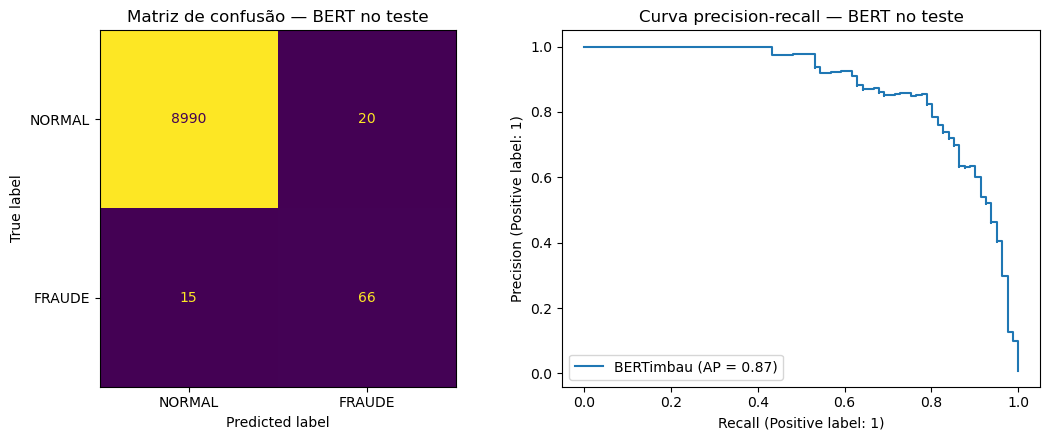

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay
from scipy.special import softmax  # já importado na PARTE 6, reimportado aqui por segurança

proba_bert_teste = softmax(resultado_bert_teste.predictions, axis=-1)[:, 1]
pred_bert_teste = np.argmax(resultado_bert_teste.predictions, axis=-1)
y_teste = df_teste["label"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay.from_predictions(y_teste, pred_bert_teste, display_labels=["NORMAL", "FRAUDE"], ax=axes[0], colorbar=False)
axes[0].set_title("Matriz de confusão — BERT no teste")
PrecisionRecallDisplay.from_predictions(y_teste, proba_bert_teste, ax=axes[1], name="BERTimbau")
axes[1].set_title("Curva precision-recall — BERT no teste")
plt.tight_layout()
plt.show()

PARTE 9.1 (NOVO) — Intervalo de confiança por bootstrap

O teste tem 175 positivos. Com tão poucos exemplos
da classe minoritária, uma diferença de F1 de alguns pontos percentuais entre duas
rodadas pode ser só ruído de amostragem. Este bootstrap reamostra o teste (com
reposição) muitas vezes e mostra a faixa em que recall e F1 realmente variam — é
essa faixa, não o número pontual, que deveria entrar no texto da pesquisa.

In [ ]:
def bootstrap_ci(y_true, pred, n_boot=2000, seed=SEED):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    pred = np.asarray(pred)
    n = len(y_true)
    f1s, recalls = [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        p, r, f1, _ = precision_recall_fscore_support(y_true[idx], pred[idx], average="binary", zero_division=0)
        f1s.append(f1)
        recalls.append(r)
    return np.array(f1s), np.array(recalls)


f1s, recalls = bootstrap_ci(y_teste, pred_bert_teste)
print(f"F1     no teste: {metricas_bert_teste['f1']:.3f}  (IC 95% bootstrap: [{np.percentile(f1s, 2.5):.3f}, {np.percentile(f1s, 97.5):.3f}])")
print(f"Recall no teste: {metricas_bert_teste['recall']:.3f}  (IC 95% bootstrap: [{np.percentile(recalls, 2.5):.3f}, {np.percentile(recalls, 97.5):.3f}])")